In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/liver-health-and-lifestyle-dataset/liver_health_dataset.csv


<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
 Setup Environment
</h1>

In [2]:
# Cell 1 - Setup
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ML & preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve, auc)
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# Optional libraries (XGBoost, LightGBM, CatBoost)
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

try:
    from catboost import CatBoostClassifier
except Exception:
    CatBoostClassifier = None

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

sns.set(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
 Load Dataset
</h1>

In [3]:
df = pd.read_csv("/kaggle/input/liver-health-and-lifestyle-dataset/liver_health_dataset.csv")
df.head()

,Bilirubin,ALT,AST,Alkaline_Phosphatase,Albumin,BMI,Alcohol_Use,Medication,Gender,Smoking,Diet,Liver_Disease_Status
0,1.94,60.0,273.0,358.0,2.60,24.2,Moderate,NaN,Male,No,Unhealthy,At_Risk
1,4.76,NaN,259.0,275.0,2.74,17.5,NaN,NaN,Female,No,Unhealthy,Diseased
2,3.69,57.0,220.0,194.0,3.94,42.1,NaN,NaN,Female,No,Healthy,At_Risk
3,3.03,28.0,34.0,394.0,3.72,37.0,Moderate,Antibiotics,Male,No,Unhealthy,At_Risk
4,0.86,NaN,161.0,297.0,4.32,44.9,Moderate,Multiple,Male,No,Healthy,At_Risk


<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Dataset Overview
</h1>

In [4]:
print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (5000, 12)


,Bilirubin,ALT,AST,Alkaline_Phosphatase,Albumin,BMI,Alcohol_Use,Medication,Gender,Smoking,Diet,Liver_Disease_Status
0,1.94,60.0,273.0,358.0,2.60,24.2,Moderate,NaN,Male,No,Unhealthy,At_Risk
1,4.76,NaN,259.0,275.0,2.74,17.5,NaN,NaN,Female,No,Unhealthy,Diseased
2,3.69,57.0,220.0,194.0,3.94,42.1,NaN,NaN,Female,No,Healthy,At_Risk
3,3.03,28.0,34.0,394.0,3.72,37.0,Moderate,Antibiotics,Male,No,Unhealthy,At_Risk
4,0.86,NaN,161.0,297.0,4.32,44.9,Moderate,Multiple,Male,No,Healthy,At_Risk


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Bilirubin             4812 non-null   float64
 1   ALT                   4850 non-null   float64
 2   AST                   4851 non-null   float64
 3   Alkaline_Phosphatase  4821 non-null   float64
 4   Albumin               4847 non-null   float64
 5   BMI                   4841 non-null   float64
 6   Alcohol_Use           3090 non-null   object 
 7   Medication            3377 non-null   object 
 8   Gender                4846 non-null   object 
 9   Smoking               4828 non-null   object 
 10  Diet                  4846 non-null   object 
 11  Liver_Disease_Status  5000 non-null   object 
dtypes: float64(6), object(6)
memory usage: 468.9+ KB


None

In [5]:
# Cell 3 - Inspect & normalize columns
# Standardize column names (strip spaces)
df.columns = [c.strip() for c in df.columns]
print("Columns:", df.columns.tolist())

# If target name slightly different, ensure it is 'Liver_Disease_Status'
if "Liver_Disease_Status" not in df.columns:
    possible = [c for c in df.columns if 'liver' in c.lower() and 'status' in c.lower()]
    if possible:
        df.rename(columns={possible[0]: "Liver_Disease_Status"}, inplace=True)
        print("Renamed", possible[0], "-> Liver_Disease_Status")

display(df.head())


Columns: ['Bilirubin', 'ALT', 'AST', 'Alkaline_Phosphatase', 'Albumin', 'BMI', 'Alcohol_Use', 'Medication', 'Gender', 'Smoking', 'Diet', 'Liver_Disease_Status']


,Bilirubin,ALT,AST,Alkaline_Phosphatase,Albumin,BMI,Alcohol_Use,Medication,Gender,Smoking,Diet,Liver_Disease_Status
0,1.94,60.0,273.0,358.0,2.60,24.2,Moderate,NaN,Male,No,Unhealthy,At_Risk
1,4.76,NaN,259.0,275.0,2.74,17.5,NaN,NaN,Female,No,Unhealthy,Diseased
2,3.69,57.0,220.0,194.0,3.94,42.1,NaN,NaN,Female,No,Healthy,At_Risk
3,3.03,28.0,34.0,394.0,3.72,37.0,Moderate,Antibiotics,Male,No,Unhealthy,At_Risk
4,0.86,NaN,161.0,297.0,4.32,44.9,Moderate,Multiple,Male,No,Healthy,At_Risk


In [6]:
# Cell 4 - Missing values and summary
print("Missing values per column:")
display(df.isnull().sum().sort_values(ascending=False))

display(df.describe(include='all').transpose())


Missing values per column:


Alcohol_Use             1910
Medication              1623
Bilirubin                188
Alkaline_Phosphatase     179
Smoking                  172
BMI                      159
Gender                   154
Diet                     154
Albumin                  153
ALT                      150
AST                      149
Liver_Disease_Status       0
dtype: int64

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Bilirubin,4812.0,NaN,NaN,NaN,2.534543,1.418545,0.1,1.3,2.54,3.77,5.0
ALT,4850.0,NaN,NaN,NaN,153.823918,83.682791,10.0,81.0,153.0,226.75,299.0
AST,4851.0,NaN,NaN,NaN,154.710369,84.73154,10.0,81.0,155.0,228.0,299.0
Alkaline_Phosphatase,4821.0,NaN,NaN,NaN,220.966397,100.75351,50.0,133.0,219.0,307.0,399.0
Albumin,4847.0,NaN,NaN,NaN,4.029171,0.869798,2.5,3.29,4.04,4.775,5.5
BMI,4841.0,NaN,NaN,NaN,30.563582,8.308563,16.0,23.4,30.6,37.6,45.0
Alcohol_Use,3090,3,Low,1428,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Medication,3377,5,Painkiller,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,4846,3,Female,2428,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Smoking,4828,3,No,2902,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Data Cleaning
</h1>

In [7]:
# Cell 5 - Missing value strategy
# Define columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'Liver_Disease_Status' in cat_cols:
    cat_cols.remove('Liver_Disease_Status')

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# Fill numeric missing with median
for c in num_cols:
    med = df[c].median()
    df[c] = df[c].fillna(med)

# Fill categorical missing with mode or 'Unknown'
for c in cat_cols:
    if df[c].mode().shape[0] > 0:
        df[c] = df[c].fillna(df[c].mode()[0])
    else:
        df[c] = df[c].fillna("Unknown")

print("Missing values after fill:")
display(df.isnull().sum())


Numerical columns: ['Bilirubin', 'ALT', 'AST', 'Alkaline_Phosphatase', 'Albumin', 'BMI']
Categorical columns: ['Alcohol_Use', 'Medication', 'Gender', 'Smoking', 'Diet']
Missing values after fill:


Bilirubin               0
ALT                     0
AST                     0
Alkaline_Phosphatase    0
Albumin                 0
BMI                     0
Alcohol_Use             0
Medication              0
Gender                  0
Smoking                 0
Diet                    0
Liver_Disease_Status    0
dtype: int64

<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Exploratory Data Analysis
</h1>

Target value counts:


Liver_Disease_Status
Diseased    2916
At_Risk     1845
Healthy      239
Name: count, dtype: int64

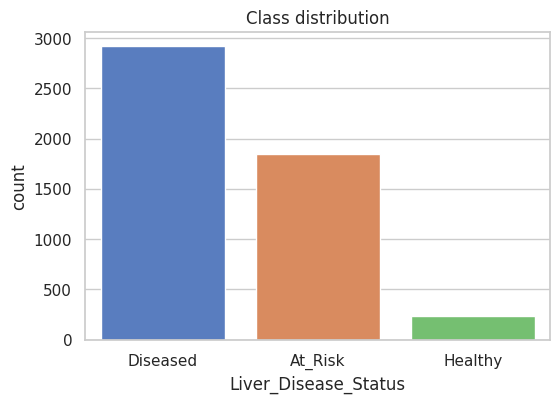

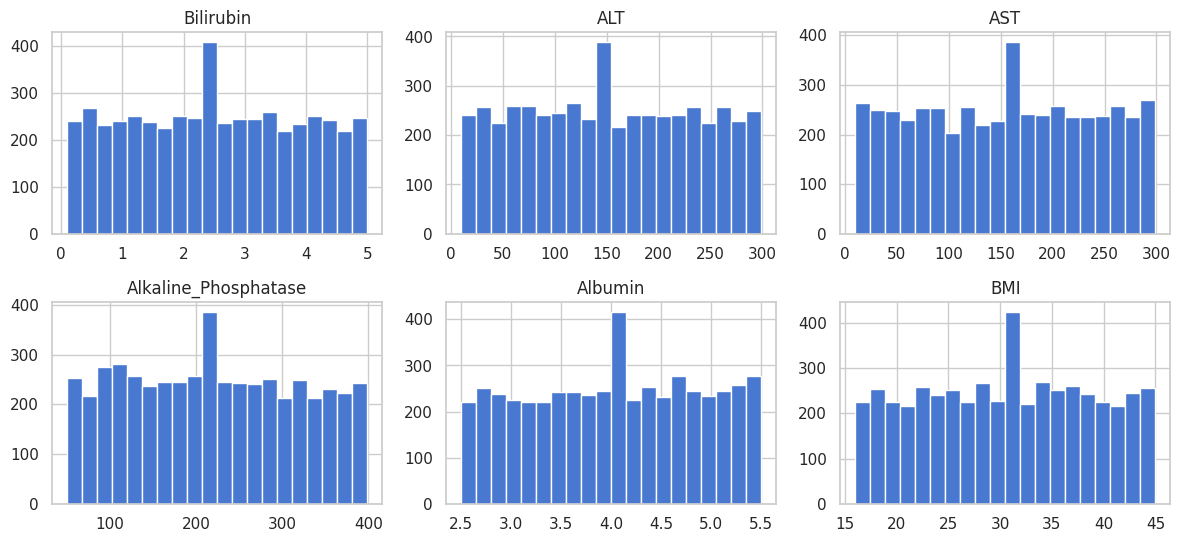

In [8]:
# Cell 6 - EDA: distributions + class balance
target = "Liver_Disease_Status"
print("Target value counts:")
display(df[target].value_counts())

# Class balance plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target, order=df[target].value_counts().index)
plt.title("Class distribution")
plt.show()

# Plot histograms for numeric cols
df[num_cols].hist(bins=20, figsize=(12, 8), layout=(len(num_cols)//3+1, 3))
plt.tight_layout()
plt.show()


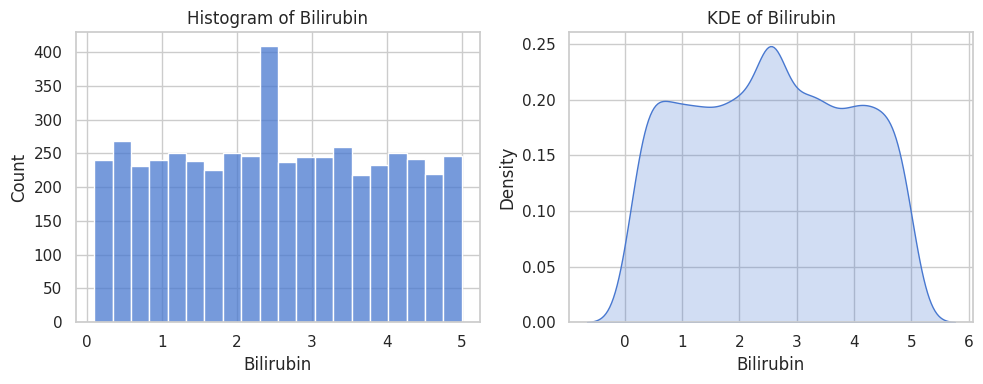

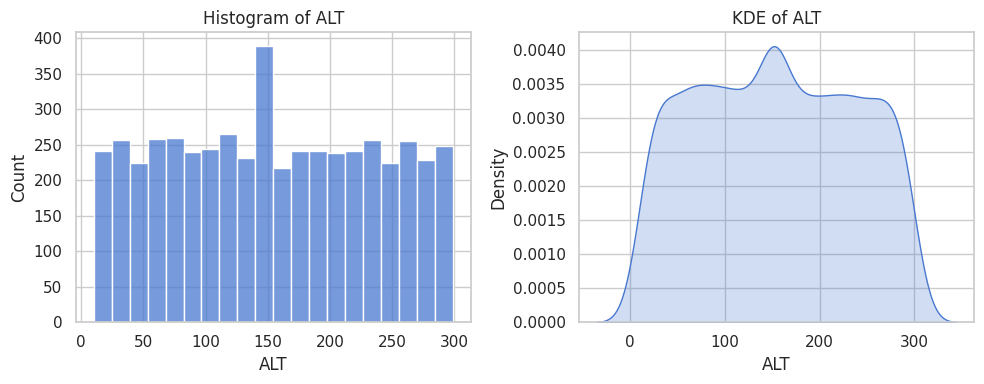

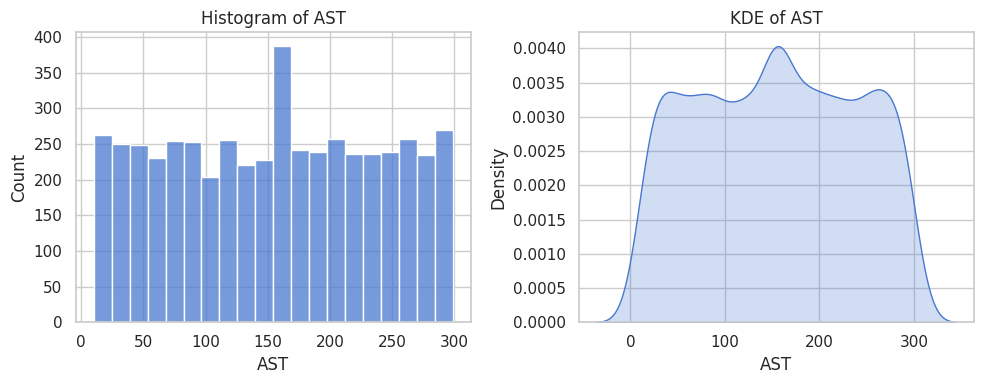

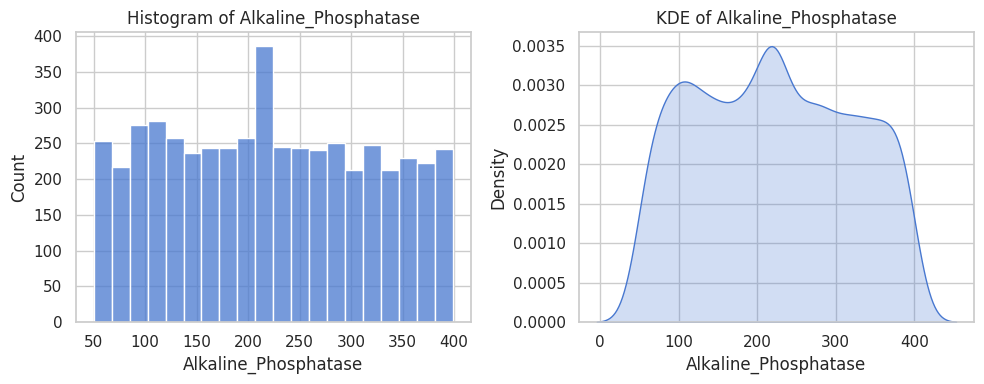

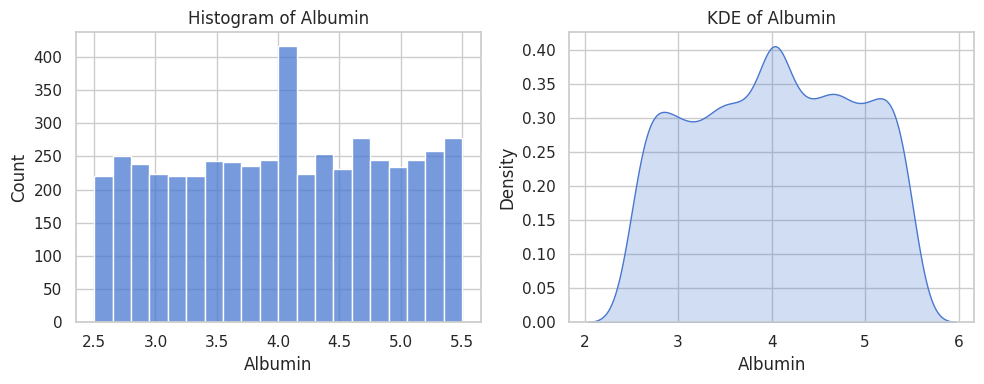

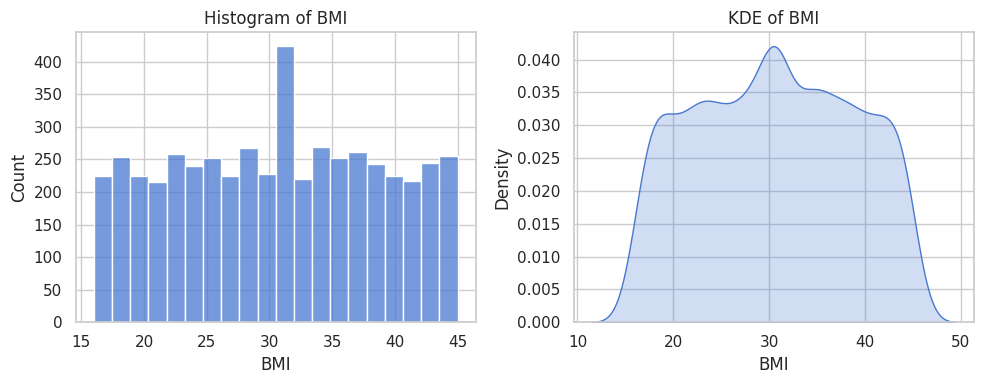

In [9]:
# Univariate analysis: distributions for numeric features
for col in num_cols:
    plt.figure(figsize=(10,4))
    
    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], bins=20, kde=False)
    plt.title(f'Histogram of {col}')
    
    # KDE
    plt.subplot(1,2,2)
    sns.kdeplot(df[col], shade=True)
    plt.title(f'KDE of {col}')
    
    plt.tight_layout()
    plt.show()


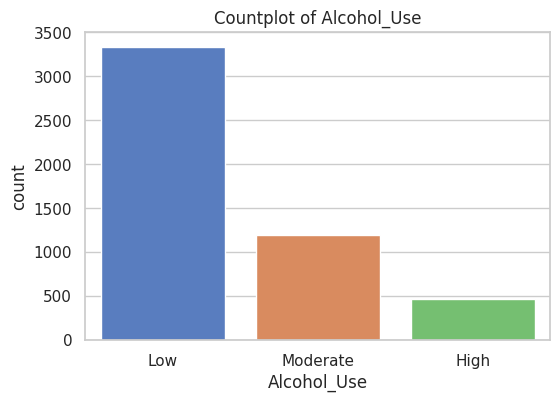

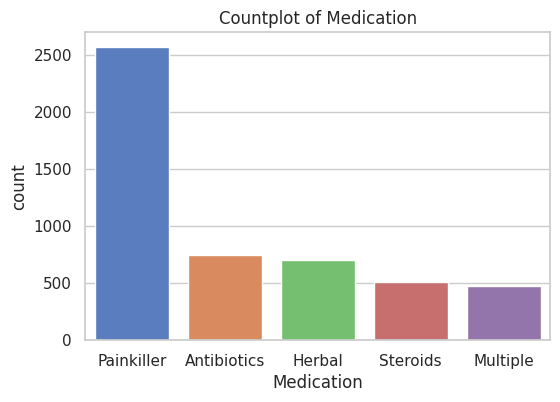

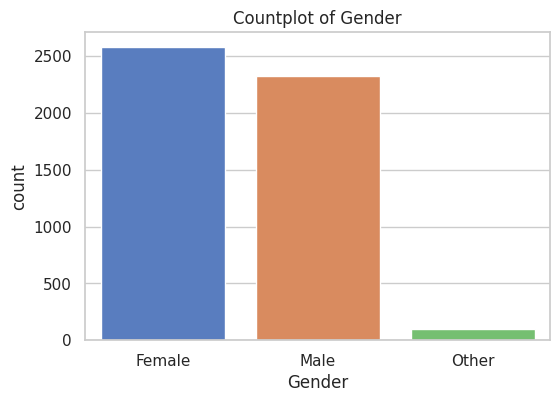

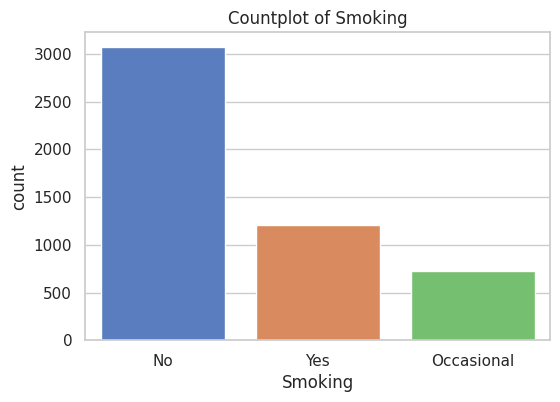

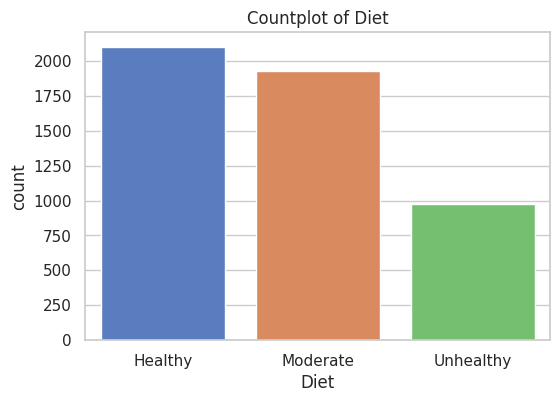

In [10]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.show()


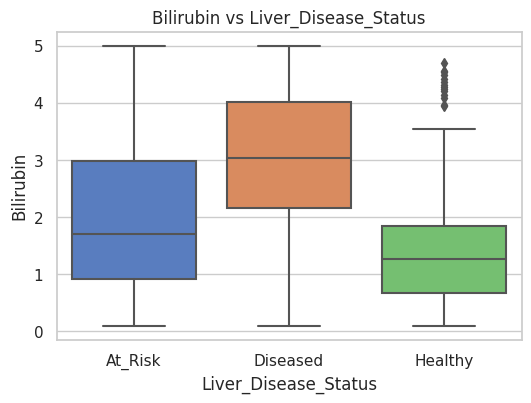

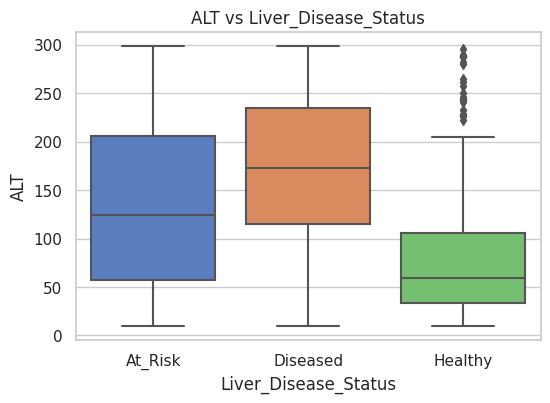

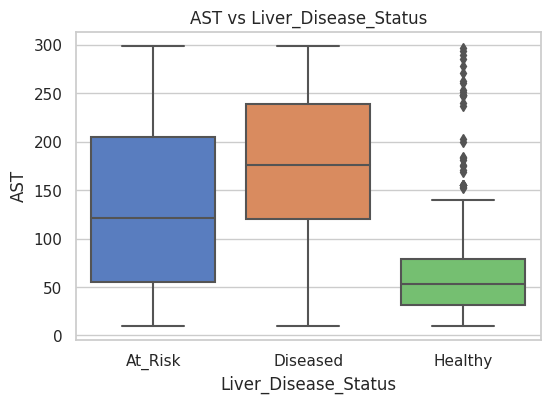

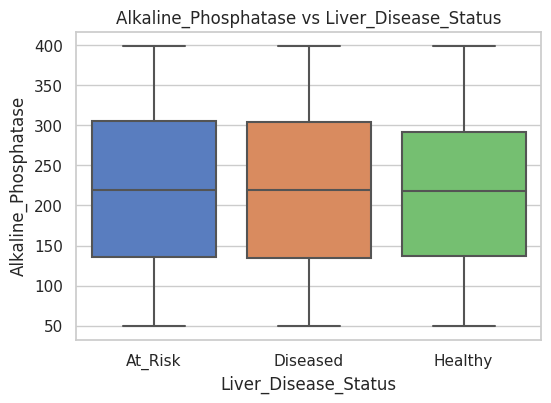

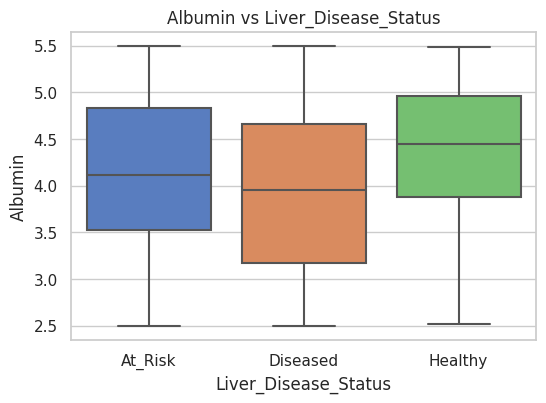

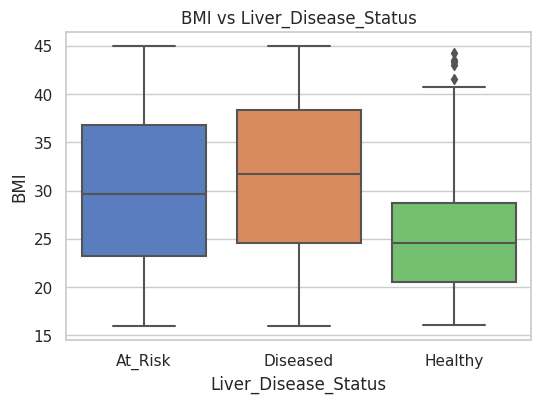

In [11]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[target], y=df[col])
    plt.title(f'{col} vs {target}')
    plt.show()


<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Outlier & Pattern Detection
</h1>

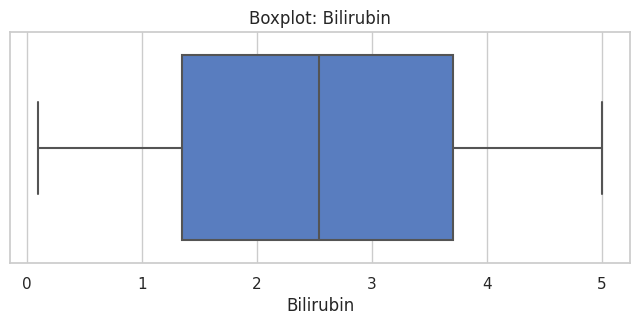

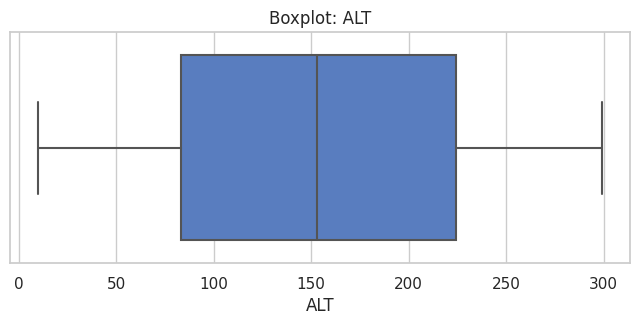

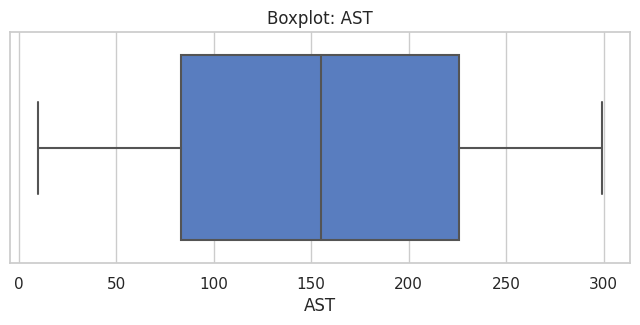

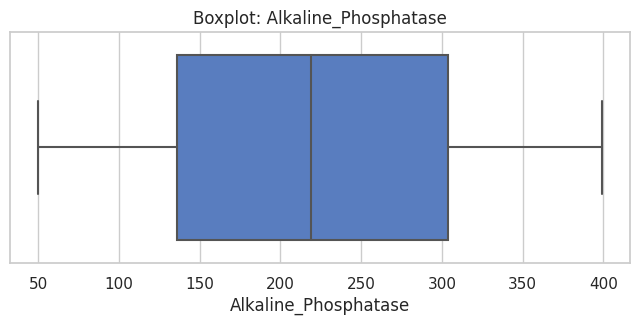

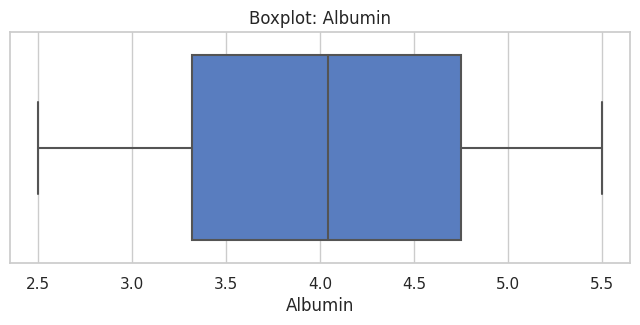

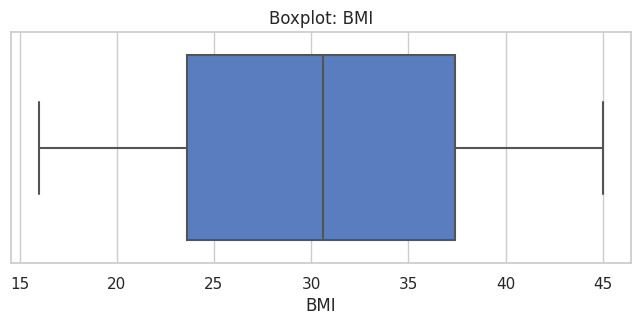

In [12]:
# Cell 8 - Boxplots for numeric features
for c in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[c])
    plt.title(f"Boxplot: {c}")
    plt.show()


<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Correlations
</h1>

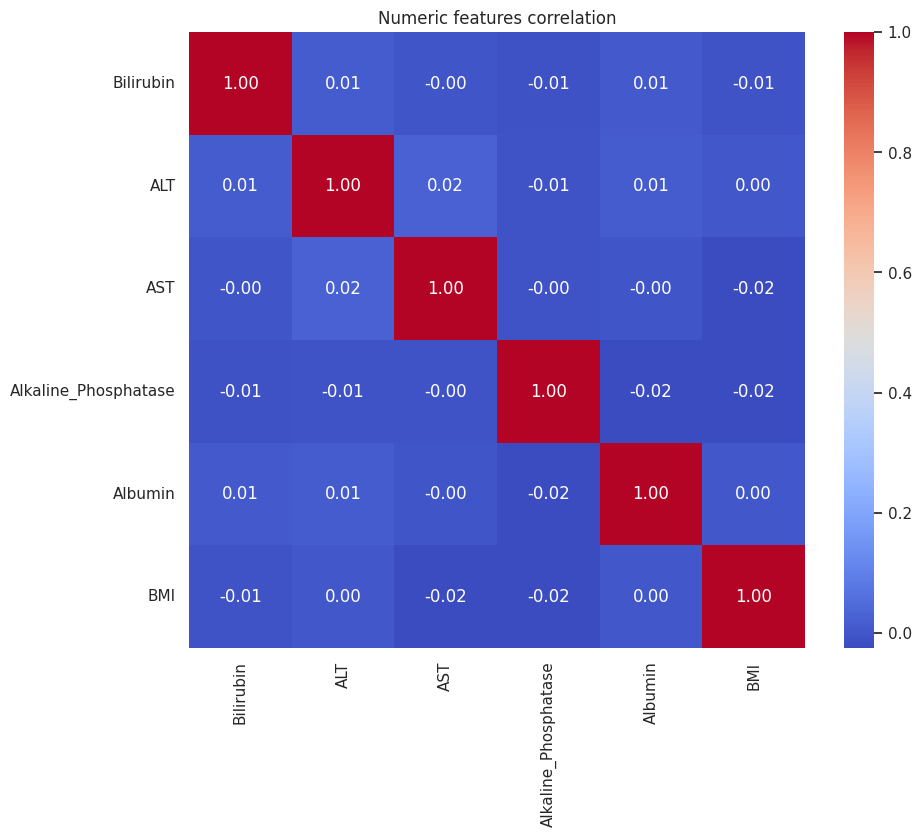

In [13]:
# Cell 7 - Correlation heatmap for numeric features
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Numeric features correlation")
plt.show()

In [14]:
# Cell 9 - Label encoding for categorical features
le_dict = {}
df_encoded = df.copy()

# Map target manually to ensure order (you can change mapping if needed)
target_map = {"Healthy": 0, "At_Risk": 1, "Diseased": 2}
if set(df_encoded[target].unique()) <= set(target_map.keys()):
    df_encoded[target] = df_encoded[target].map(target_map)
else:
    # fallback: label encode target
    le_target = LabelEncoder()
    df_encoded[target] = le_target.fit_transform(df_encoded[target])
    target_map = {cls: int(label) for cls, label in zip(le_target.classes_, le_target.transform(le_target.classes_))}
    print("Target mapping (auto):", target_map)

for c in cat_cols:
    le = LabelEncoder()
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))
    le_dict[c] = le

print("Encoded categorical columns.")
display(df_encoded.head())


Encoded categorical columns.


,Bilirubin,ALT,AST,Alkaline_Phosphatase,Albumin,BMI,Alcohol_Use,Medication,Gender,Smoking,Diet,Liver_Disease_Status
0,1.94,60.0,273.0,358.0,2.60,24.2,2,3,1,0,2,1
1,4.76,153.0,259.0,275.0,2.74,17.5,1,3,0,0,2,2
2,3.69,57.0,220.0,194.0,3.94,42.1,1,3,0,0,0,1
3,3.03,28.0,34.0,394.0,3.72,37.0,2,0,1,0,2,1
4,0.86,153.0,161.0,297.0,4.32,44.9,2,2,1,0,0,1


<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Lifestyle Impact
</h1>

In [15]:
# Cell 10 - Prepare X and y, scaling numerics with MinMax
X = df_encoded.drop(columns=[target]).copy()
y = df_encoded[target].copy()

# MinMax scaling for numeric columns only
scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

# Save scaler for future use
joblib.dump(scaler, "scaler.gz")
print("Saved scaler to scaler.gz")


Feature matrix shape: (5000, 11)
Target shape: (5000,)
Saved scaler to scaler.gz


<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Data Preprocessing
</h1>

In [16]:
# Cell 11 - Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (4000, 11) Test shape: (1000, 11)


<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
   Feature Engineering
</h1>

<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Build 10 ML Models
</h1>

In [17]:
# Cell 12 - Define models
models = {
    "LogisticRegression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "NaiveBayes": GaussianNB()
}

# Add XGBoost, LightGBM, CatBoost if available
if XGBClassifier is not None:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=RANDOM_STATE)
else:
    print("XGBoost not available in this environment.")

if LGBMClassifier is not None:
    models["LightGBM"] = LGBMClassifier(random_state=RANDOM_STATE)
else:
    print("LightGBM not available in this environment.")

if CatBoostClassifier is not None:
    models["CatBoost"] = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
else:
    print("CatBoost not available in this environment.")

models


{'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
 'KNN': KNeighborsClassifier(),
 'SVC': SVC(probability=True, random_state=42),
 'DecisionTree': DecisionTreeClassifier(random_state=42),
 'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
 'GradientBoosting': GradientBoostingClassifier(random_state=42),
 'NaiveBayes': GaussianNB(),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, m

<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Model Evaluation
</h1>

In [18]:
# Cell 13 - Train & evaluate (basic training)
results = []
fitted_models = {}

for name, model in models.items():
    print(f"Training {name} ...")
    try:
        model.fit(X_train, y_train)
    except Exception as e:
        print(f"Failed to train {name}: {e}")
        continue

    fitted_models[name] = model
    y_pred = model.predict(X_test)
    # For precision/recall with multiclass, use macro average
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    results.append({
        "model": name,
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1
    })
    print(f"{name} -> acc:{acc:.4f}, f1:{f1:.4f}")

results_df = pd.DataFrame(results).sort_values(by="accuracy", ascending=False).reset_index(drop=True)
display(results_df)


Training LogisticRegression ...
LogisticRegression -> acc:0.7550, f1:0.6779
Training KNN ...
KNN -> acc:0.7250, f1:0.5437
Training SVC ...
SVC -> acc:0.7900, f1:0.5566
Training DecisionTree ...
DecisionTree -> acc:0.9250, f1:0.8701
Training RandomForest ...
RandomForest -> acc:0.9670, f1:0.9338
Training GradientBoosting ...
GradientBoosting -> acc:0.9600, f1:0.9033
Training NaiveBayes ...
NaiveBayes -> acc:0.8090, f1:0.6868
Training XGBoost ...
XGBoost -> acc:0.9600, f1:0.9196
Training LightGBM ...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1468
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 11
[LightGBM] [Info] Start training from score -3.041776
[LightGBM] [Info] Start training from score -0.996959
[LightGBM] [Info] Start training fro

,model,accuracy,precision_macro,recall_macro,f1_macro
0,CatBoost,0.971,0.946160,0.940209,0.943150
1,RandomForest,0.967,0.936414,0.931218,0.933783
2,LightGBM,0.967,0.932171,0.937259,0.934684
3,GradientBoosting,0.960,0.930235,0.881944,0.903256
4,XGBoost,0.960,0.919027,0.920180,0.919590
5,DecisionTree,0.925,0.865567,0.874750,0.870052
6,NaiveBayes,0.809,0.809012,0.645016,0.686753
7,SVC,0.790,0.849939,0.558271,0.556563
8,LogisticRegression,0.755,0.726777,0.649393,0.677917
9,KNN,0.725,0.560314,0.535396,0.543664


Model: CatBoost
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.88      0.88        48
           1       0.96      0.96      0.96       369
           2       0.98      0.99      0.98       583

    accuracy                           0.97      1000
   macro avg       0.95      0.94      0.94      1000
weighted avg       0.97      0.97      0.97      1000



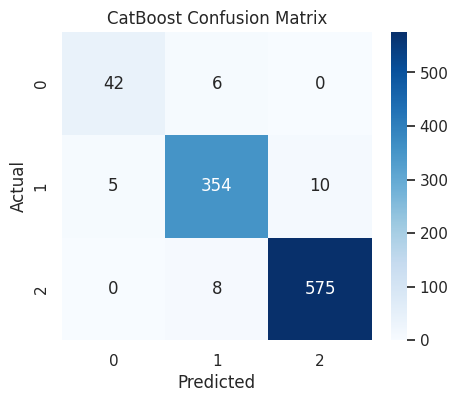

Model: RandomForest
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86        48
           1       0.95      0.96      0.96       369
           2       0.98      0.98      0.98       583

    accuracy                           0.97      1000
   macro avg       0.94      0.93      0.93      1000
weighted avg       0.97      0.97      0.97      1000



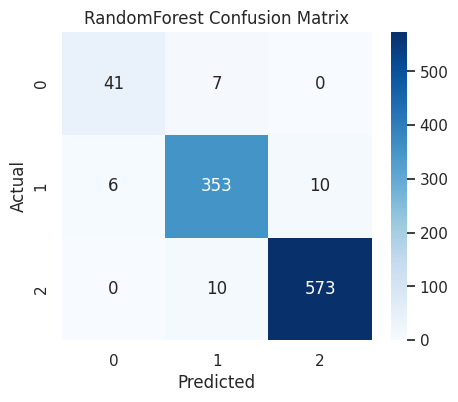

Model: LightGBM
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        48
           1       0.96      0.95      0.96       369
           2       0.98      0.98      0.98       583

    accuracy                           0.97      1000
   macro avg       0.93      0.94      0.93      1000
weighted avg       0.97      0.97      0.97      1000



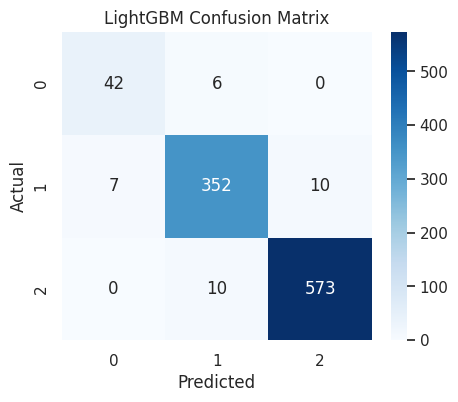

In [19]:
# Cell 14 - Detailed reports for top 3 models
top_n = min(3, results_df.shape[0])
top_models = results_df['model'].tolist()[:top_n]

for name in top_models:
    print("="*60)
    print(f"Model: {name}")
    model = fitted_models[name]
    y_pred = model.predict(X_test)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [20]:
# Cell 15 - ROC AUC multiclass (One-vs-Rest)
# Binarize labels for multiclass ROC
classes = np.unique(y)
y_test_binarized = label_binarize(y_test, classes=classes)
n_classes = y_test_binarized.shape[1]

plt.figure(figsize=(10,8))

for name in results_df['model'].tolist():
    if name not in fitted_models:
        continue
    model = fitted_models[name]
    # get probability estimates
    try:
        y_score = model.predict_proba(X_test)
    except Exception:
        # some models (SVC without probability) fallback: decision_function
        try:
            y_score = model.decision_function(X_test)
            # convert to probability-like with softmax if needed
            from scipy.special import softmax
            if y_score.ndim == 1:
                # binary case -> stack
                y_score = np.vstack([1 - y_score, y_score]).T
            else:
                y_score = softmax(y_score, axis=1)
        except Exception:
            print(f"Skipping ROC for {name} (no predict_proba/decision_function).")
            continue

    try:
        auc_score = roc_auc_score(y_test_binarized, y_score, average='macro', multi_class='ovr')
    except Exception as e:
        print(f"ROC AUC compute failed for {name}: {e}")
        continue

    print(f"{name} ROC AUC (macro OVR): {auc_score:.4f}")

    # For plotting only plot top model to keep visuals clear (optional): comment/uncomment next lines
    # RocCurveDisplay.from_predictions(y_test, y_score[:,1], name=name)  # not used for multiclass generic


CatBoost ROC AUC (macro OVR): 0.9931
RandomForest ROC AUC (macro OVR): 0.9935
LightGBM ROC AUC (macro OVR): 0.9916
GradientBoosting ROC AUC (macro OVR): 0.9906
XGBoost ROC AUC (macro OVR): 0.9906
DecisionTree ROC AUC (macro OVR): 0.9153
NaiveBayes ROC AUC (macro OVR): 0.9203
SVC ROC AUC (macro OVR): 0.9209
LogisticRegression ROC AUC (macro OVR): 0.8893
KNN ROC AUC (macro OVR): 0.7915


<Figure size 1000x800 with 0 Axes>

<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Select Best Model
</h1>

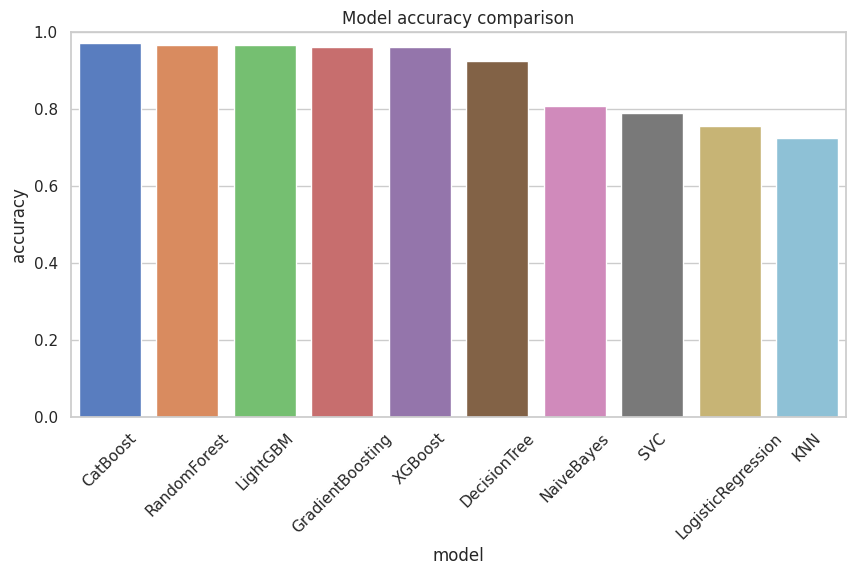

Saved model_comparison_results.csv


In [21]:
# Cell 16 - Accuracy comparison plot
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='model', y='accuracy')
plt.xticks(rotation=45)
plt.title("Model accuracy comparison")
plt.ylim(0,1)
plt.show()

# Save results
results_df.to_csv("model_comparison_results.csv", index=False)
print("Saved model_comparison_results.csv")


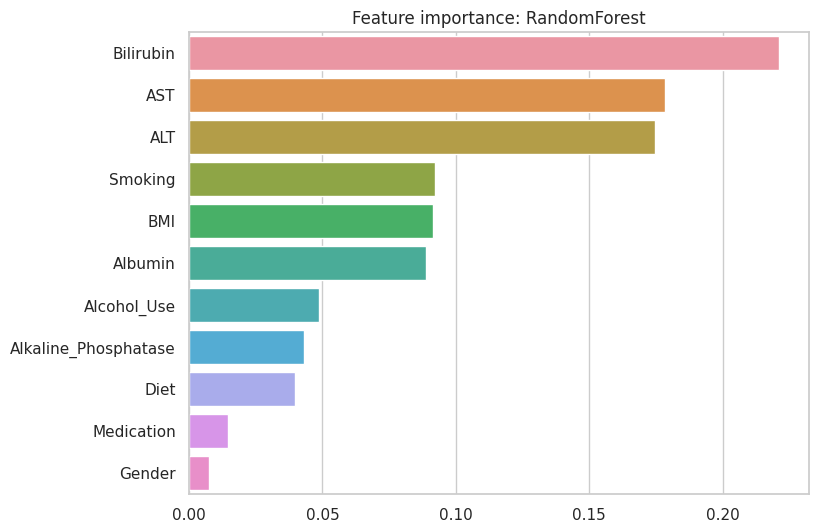

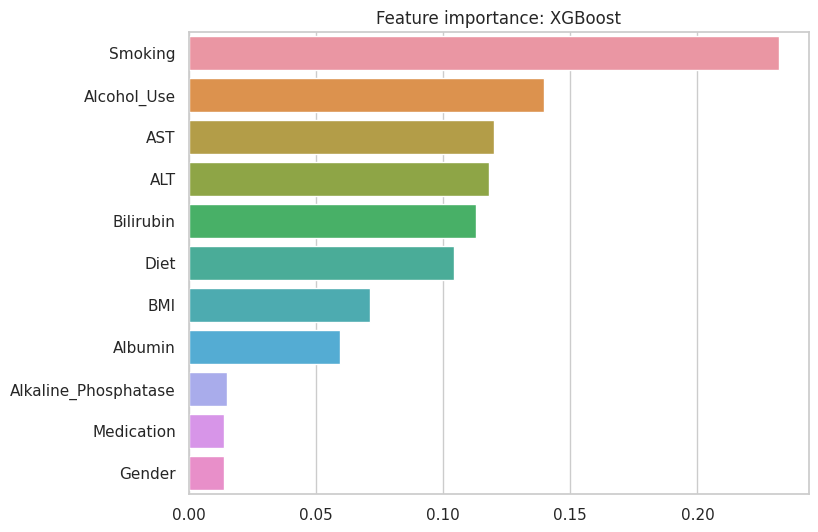

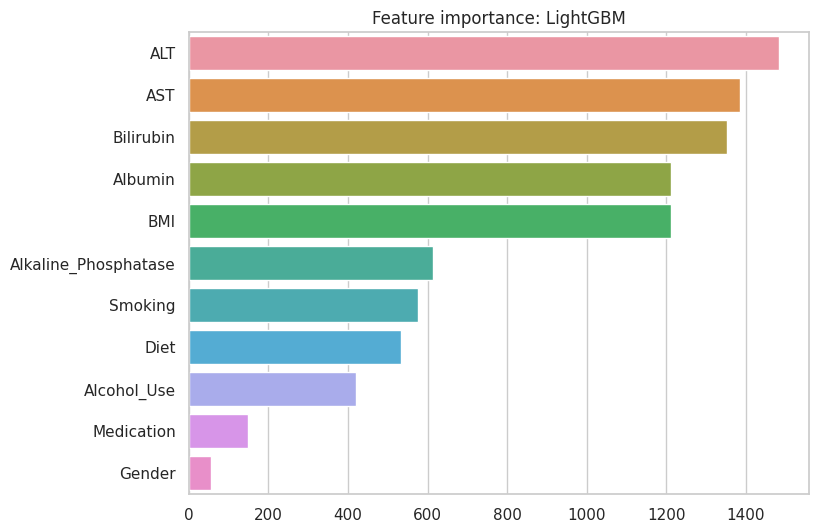

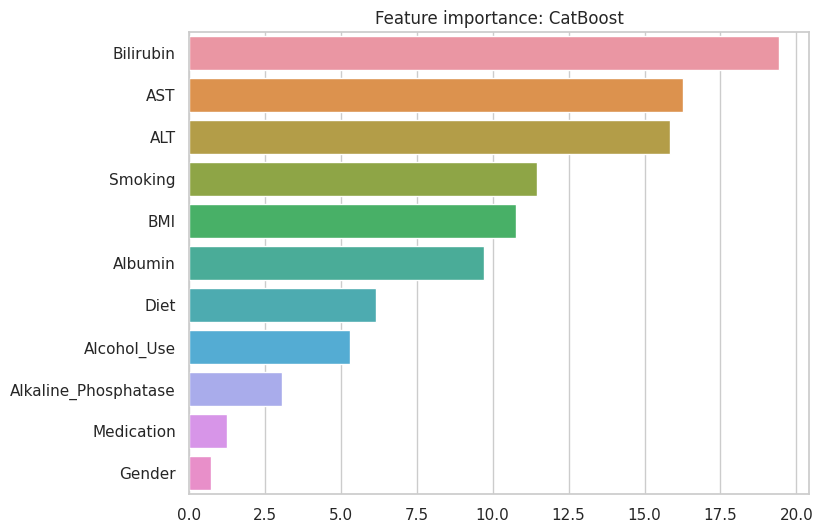

In [22]:
# Cell 17 - Feature importance (RandomForest / XGBoost / LightGBM / CatBoost if present)
def plot_feature_importance(model, model_name, topn=15):
    if hasattr(model, "feature_importances_"):
        imp = model.feature_importances_
    elif hasattr(model, "get_feature_importance"):  # catboost
        try:
            imp = model.get_feature_importance()
        except Exception:
            return
    else:
        print(f"{model_name} doesn't provide feature importances.")
        return

    feat_imp = pd.Series(imp, index=X.columns).sort_values(ascending=False)[:topn]
    plt.figure(figsize=(8,6))
    sns.barplot(x=feat_imp.values, y=feat_imp.index)
    plt.title(f"Feature importance: {model_name}")
    plt.show()

for name in ["RandomForest", "XGBoost", "LightGBM", "CatBoost"]:
    if name in fitted_models:
        plot_feature_importance(fitted_models[name], name)


<h1 style="color: white; background-color: #33cc33; text-align: center; padding: 12px; border-radius: 10px;">
  Save the Best Model
</h1>

In [23]:
# Cell 18 - Save the best model (by accuracy)
best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
joblib.dump(best_model, f"{best_model_name}_model.gz")
print(f"Saved best model: {best_model_name}_model.gz")

# Save label encoders and mapping
joblib.dump(le_dict, "label_encoders.gz")
joblib.dump(target_map, "target_map.gz")
print("Saved label encoders and target map.")


Saved best model: CatBoost_model.gz
Saved label encoders and target map.


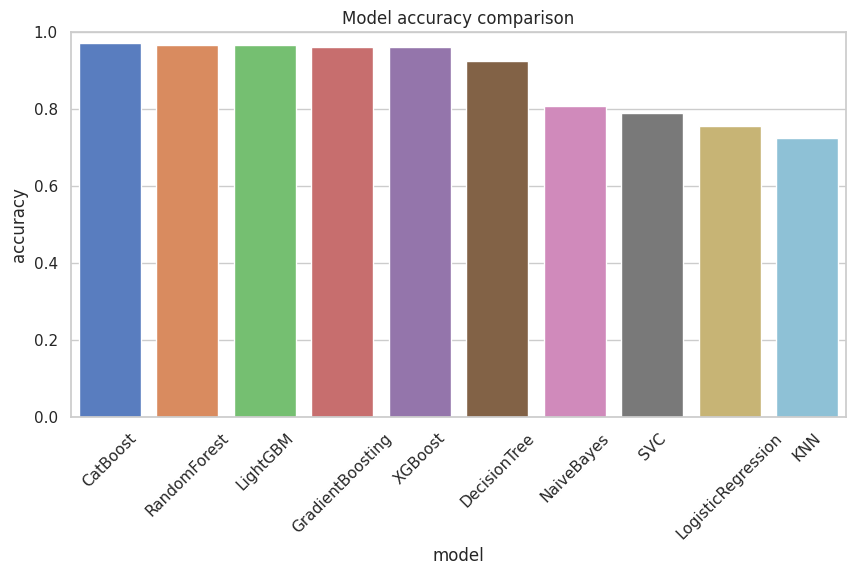

Saved model_comparison_results.csv


In [24]:
# Cell 16 - Accuracy comparison plot
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='model', y='accuracy')
plt.xticks(rotation=45)
plt.title("Model accuracy comparison")
plt.ylim(0,1)
plt.show()

# Save results
results_df.to_csv("model_comparison_results.csv", index=False)
print("Saved model_comparison_results.csv")


# Conclusion & Next steps

**Summary**
- Performed full EDA, missing-value handling, categorical encoding, scaling.
- Trained 10 classification models and compared performance (accuracy, precision, recall, F1).
- Saved best model and preprocessing artifacts (scaler + encoders).
- Optional: SHAP explainability for deeper feature insights.

**Next steps / improvements**
- Hyperparameter tuning (GridSearchCV/RandomizedSearchCV) for top models.
- Stratified K-Fold cross validation and averaged CV scores for robust comparison.
- Try class-weight or SMOTE if classes are imbalanced.
- Add probability calibration if required.
- Deploy best model (Flask/FastAPI) and provide prediction API.

**Files saved**
- scaler.gz
- model_comparison_results.csv
- {best_model_name}_model.gz
- label_encoders.gz
- target_map.gz
